# MNE-Python: scientific scope, software design and the EEG data model

**ROBT613 · Academic tutorial and independent exercises**

## Learning outcomes

Explain the purpose of MNE-Python; distinguish acquisition, representation, processing and inference; construct and inspect `Info`, `Raw`, `Epochs` and `Evoked`; interpret physical units and event coordinates; preserve independent analysis branches; and export reproducible derivatives. Basic Python, linear algebra and elementary EEG physiology are assumed and reviewed where needed.

This notebook precedes the paradigm-specific lessons. Execute it from beginning to end in a fresh CPU runtime. Every exercise includes a reference answer in the notebook. The sensor-level scope excludes source-imaging tutorials.

## Scientific scope and experimental context

MNE-Python is an open-source scientific software library for analysing electrophysiological and related neurophysiological recordings. Its purpose includes data import, metadata management, preprocessing, event segmentation, spectral and time–frequency analysis, visualization, statistics and decoding. Supported modalities include EEG, MEG, intracranial electrophysiology and fNIRS. Different modalities require different physical measurement models; a shared software interface does not make their units or physiology interchangeable.

A BCI analysis combines an experimentally defined task with a prediction problem. MNE represents and processes the signals; the experiment provides the labels and timing. MOABB supplies additional dataset adapters and benchmark paradigms, scikit-learn supplies general machine-learning estimators, and PyTorch supports neural-network modelling. Those packages are distinct projects. A dataset available through MOABB is not necessarily bundled with MNE, and a downloadable example is not necessarily a BCI Competition dataset.

The design described here follows the public API rather than private implementation details. See [Gramfort et al. (2013)](https://doi.org/10.3389/fnins.2013.00267) and the [MNE overview](https://mne.tools/stable/auto_tutorials/intro/10_overview.html).

## Experimental setup used for the recorded example

The example uses PhysioNet EEGBCI subject 1, run 4: cued imagined left/right fist movement. The original recording contains 64 scalp EEG channels sampled at 160 Hz and was acquired using BCI2000. A minimal comparable design requires an EEG cap and amplifier, a cue display, a participant performing instructed imagery and synchronized event markers. The source protocol, rather than an EEG plot, determines the meaning of each event. Runs 4, 8 and 12 in this database are the repeated left/right imagery runs; executed movement appears in other runs.

Motor imagery can modulate sensorimotor oscillatory power without producing a large phase-consistent voltage average. Consequently, the evoked display below demonstrates a data representation, while the spectrum describes oscillatory content. Neither plot alone demonstrates reliable intention classification. See the [PhysioNet acquisition record](https://physionet.org/content/eegmmidb/1.0.0/).

## Setup

The environment cell installs the tested versions only in Colab. The recorded example downloads public EEG data on its first execution and subsequently uses the local cache. Synthetic arrays in the initial exercises are labelled explicitly and are not substitutes for an unavailable recording.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


## Architecture: representations and transformations

The principal design separates numerical samples from the metadata required to interpret them. Public objects expose methods that operate on both consistently. A montage specifies sensor positions; it is not a voltage reference. An EEG reference defines the potential difference represented by the samples. Event markers provide temporal coordinates and labels; they are not additional EEG observations.

| Representation | Numerical organisation | Principal interpretation |
|---|---|---|
| `Info` | Metadata, not a signal matrix | Sampling frequency, channel names/types, bad channels and sensor information |
| `Raw` | channels × samples | Continuous recording with acquisition timing and annotations |
| `Epochs` | trials × channels × samples | Event-aligned segments with event identifiers and optional trial metadata |
| `Evoked` | channels × samples | An averaged response with the number of contributing epochs |
| `Spectrum` / `EpochsSpectrum` | channel/frequency or trial/channel/frequency | Spectral estimates with frequency coordinates |
| Time–frequency objects | channel/frequency/time, optionally trial | Time-resolved spectral representations |

Most computation can be expressed as transformations between these objects. Array conversion enables interoperability, but loses the implicit association between samples and metadata unless it is preserved separately. Do not infer axis meaning from an array's dimensions alone.

### Package responsibilities

`mne.io` reads recording formats; `mne.preprocessing` provides artifact-related operations; `mne.time_frequency` provides spectral representations; `mne.decoding` connects neurophysiological representations with machine-learning workflows; `mne.viz` provides scientific displays; and `mne.stats` provides statistical procedures. Dataset-fetching utilities are access mechanisms, not acquisition hardware. The library does not establish a valid experimental design automatically.

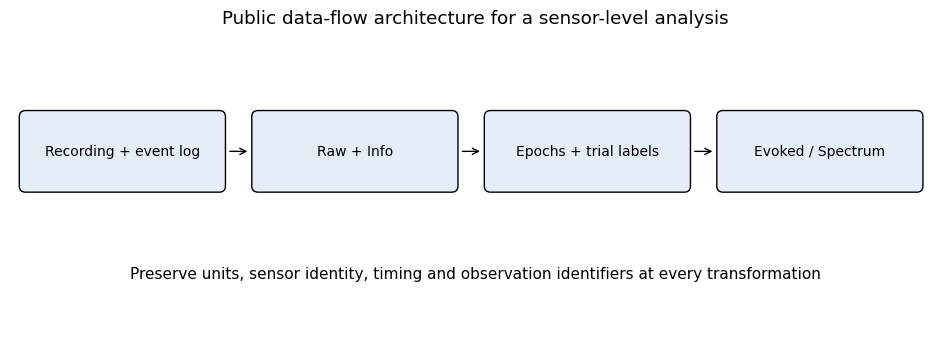

In [2]:
from matplotlib.patches import FancyBboxPatch
fig, ax = plt.subplots(figsize=(12, 4))
ax.set(xlim=(0, 12), ylim=(0, 4)); ax.axis('off')
boxes = [(0.2, 2, 'Recording + event log'), (3.2, 2, 'Raw + Info'),
         (6.2, 2, 'Epochs + trial labels'), (9.2, 2, 'Evoked / Spectrum')]
for x, y, label in boxes:
    ax.add_patch(FancyBboxPatch((x, y), 2.5, 0.9, boxstyle='round,pad=0.08', facecolor='#e5eef8'))
    ax.text(x + 1.25, y + 0.45, label, ha='center', va='center', fontsize=10)
for x in [2.8, 5.8, 8.8]:
    ax.annotate('', xy=(x + 0.3, 2.45), xytext=(x, 2.45), arrowprops={'arrowstyle': '->'})
ax.text(6, 0.8, 'Preserve units, sensor identity, timing and observation identifiers at every transformation', ha='center')
ax.set_title('Public data-flow architecture for a sensor-level analysis')
plt.show()

## Mathematical review: measurements, coordinates and arrays

Let $v_c(t)$ denote the potential at sensor $c$ and $v_r(t)$ the reference potential. The sampled EEG is

$$x_c[n]=v_c(n/f_s)-v_r(n/f_s),\qquad n=0,\ldots,T-1.$$

Here $f_s$ is samples per second, $n$ is a sample index and voltage is expressed in volts. Conversion to microvolts is $x_{\mu V}=10^6x_V$. The interval between the first and last sample is $(T-1)/f_s$, whereas $T/f_s$ is the duration represented by $T$ sampling intervals. This distinction explains apparently off-by-one epoch dimensions.

For an onset sample $s_i$ and relative sample offsets $k_a,\ldots,k_b$,

$$X_i[c,k]=x_c[s_i+k],\qquad t_k=k/f_s.$$

MNE event arrays use integer sample coordinates and event codes. `Raw.first_samp` can be nonzero; converting event samples to a time relative to the beginning of the current object requires accounting for this offset. `Annotations` describe onset, duration and text labels; `events_from_annotations` converts selected descriptions into discrete events. The resulting mapping must be inspected rather than assumed.

For $N$ epochs, the evoked response is $\bar X=N^{-1}\sum_iX_i$. It is a reduction over the trial axis. Averaging channels instead produces a different quantity. In double precision, the signal array alone requires approximately $8NCT$ bytes; object metadata and temporary copies require additional memory.

### Exercise 1: units and memory

For 100 epochs, 64 channels and 321 samples per epoch, calculate the memory occupied by a float64 array. Convert 25 microvolts to volts. Explain why feeding numerical microvolt values into a constructor expecting volts is erroneous.

In [3]:
# Independent calculation: replace these values before reading the answer.
memory_bytes_attempt = None
volts_attempt = None

### Reference answer

The array contains 2,054,400 numbers and requires 16,435,200 bytes, approximately 15.67 MiB. Twenty-five microvolts equals 0.000025 volts. A unit error of one million changes filtering diagnostics, rejection thresholds and amplitude interpretation even when an array has the expected shape.

In [4]:
memory_bytes = 100 * 64 * 321 * 8
volts = 25e-6
assert memory_bytes == 16435200
assert np.isclose(volts * 1e6, 25)
print(f'{memory_bytes / 2**20:.2f} MiB; {volts:.6f} V')

15.67 MiB; 0.000025 V


## Controlled construction: metadata and continuous data

The next array is synthetic. Its known frequency and amplitude allow direct verification of the representation. `create_info` records sampling frequency and channel types. `RawArray` associates those definitions with a channel-by-time array. The number and order of names must match the first array dimension. Setting a montage attaches nominal electrode coordinates; it does not change the voltage samples.

In [5]:
sfreq_demo = 160.0
time_demo = np.arange(1600) / sfreq_demo
signal_demo = 10e-6 * np.sin(2 * np.pi * 10 * time_demo)
info_demo = mne.create_info(['C3', 'C4'], sfreq_demo, ch_types='eeg')
raw_demo = mne.io.RawArray(np.vstack([signal_demo, 0.7 * signal_demo]), info_demo, verbose=False)
raw_demo.set_montage('standard_1005')
print(raw_demo)
print(raw_demo.get_data().shape, raw_demo.get_channel_types())

<RawArray | 2 x 1600 (10.0 s), ~33 KiB, data loaded>
(2, 1600) ['eeg', 'eeg']


/tmp/ipykernel_477620/3988896853.py:6: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_demo.set_montage('standard_1005')


### Exercise 2: object identity and mutation

Many MNE processing methods modify an object in place and return that object. Assigning `other = raw_demo` creates another reference to the same object. It does not create an independent recording. Predict whether cropping `other` would change the duration of `raw_demo`. Then construct a safe processing branch.

### Reference answer

Both variable names identify the same object, so an in-place crop through either name is visible through the other. Use `.copy()` before modifications that must not affect the original. Copying preloaded data can have a substantial memory cost. This behavioural contract is documented in the [in-place modification tutorial](https://mne.tools/stable/auto_tutorials/intro/15_inplace.html).

In [6]:
raw_branch = raw_demo.copy().crop(tmin=0, tmax=2)
assert raw_branch is not raw_demo
assert raw_branch.n_times < raw_demo.n_times
print('Original samples:', raw_demo.n_times, 'Branch samples:', raw_branch.n_times)

Original samples: 1600 Branch samples: 321


## Apply the ideas to a recorded experiment

The next cells read an actual motor-imagery recording. The source remains an EDF file; the reader exposes a common `Raw` interface. `preload=True` loads samples into memory so subsequent processing can operate directly. A lazy reader can reduce initial memory use, but many transformations require loading data.

### Acquisition inspection

Inspect channel names, sampling frequency and annotations before choosing analysis parameters. Standardizing dataset-specific names allows them to match a standard montage. Nominal positions are useful for sensor displays but are not individually digitized anatomy.

In [7]:
from mne.datasets import eegbci
paths = eegbci.load_data(1, [4], path=DATA_ROOT, update_path=False, verbose=False)
raw = mne.io.read_raw_edf(paths[0], preload=True, verbose=False)
eegbci.standardize(raw)
raw.set_montage('standard_1005')
print('Sampling frequency:', raw.info['sfreq'])
print('Channels:', len(raw.ch_names), raw.ch_names[:8])
print('Annotations:', set(raw.annotations.description))

Sampling frequency: 160.0
Channels: 64 ['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5']
Annotations: {'T2', 'T0', 'T1'}


/tmp/ipykernel_477620/4195119311.py:5: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw.set_montage('standard_1005')


### MNE visualization of continuous EEG

The static browser view displays a short recorded interval. Its vertical scaling is specified in volts, while displayed EEG labels use microvolts. Large excursions require contextual inspection; amplitude alone cannot identify an artifact source. The use of a Matplotlib backend supports notebook rendering without a desktop GUI.

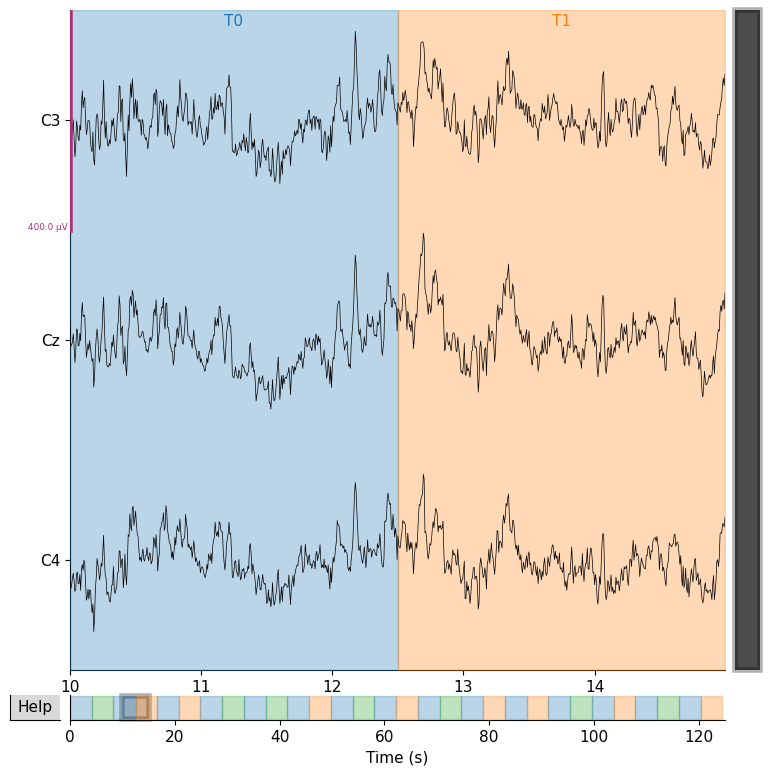

In [8]:
with mne.viz.use_browser_backend('matplotlib'):
    raw.copy().pick(['C3', 'Cz', 'C4']).plot(start=10, duration=5, n_channels=3,
        scalings={'eeg': 200e-6}, show=False, block=False)
plt.show()

## From annotations to epochs

For this run, T1 and T2 denote left- and right-fist imagery. T0 denotes rest and is excluded from the two-class event mapping. A dictionary states the mapping explicitly. The analysis window begins 0.5 seconds after the cue and ends at 3.5 seconds; it is an analysis choice, not the full acquisition protocol. A copy preserves the original recording before filtering.

Baseline subtraction is disabled here because subsequent power analysis does not require removal of a prestimulus voltage mean. This does not imply that baseline normalization of power is unnecessary in an ERD experiment: those are distinct operations.

In [9]:
events, event_id = mne.events_from_annotations(raw, event_id={'T1': 1, 'T2': 2}, verbose=False)
processed = raw.copy().filter(8, 30, verbose=False)
epochs = mne.Epochs(processed, events, event_id={'left': 1, 'right': 2},
                    tmin=0.5, tmax=3.5, baseline=None, preload=True, verbose=False)
print(epochs)
print('Epoch array:', epochs.get_data(copy=True).shape)

<Epochs | 15 events (all good), 0.5 – 3.5 s (baseline off), ~3.6 MiB, data loaded,
 'left': 8
 'right': 7>
Epoch array: (15, 64, 481)


### Exercise 3: dimensions and event alignment

Predict the number of samples in an inclusive 0.5–3.5 second epoch at 160 Hz. Identify which axis is averaged by `epochs.average()`. Explain why attaching labels after arbitrarily sorting an array would invalidate the analysis.

### Reference answer

There are 481 samples: 480 sampling intervals plus the included endpoint. `average()` reduces the trial axis. Trial labels correspond to the original epoch order; reordering only samples breaks this correspondence. Labels must be reordered by the identical index operation.

In [10]:
expected_samples = round((3.5 - 0.5) * epochs.info['sfreq']) + 1
assert len(epochs.times) == expected_samples
array = epochs.get_data(copy=True)
evoked = epochs.average()
assert np.allclose(evoked.data, array.mean(axis=0))
print('Samples per epoch:', expected_samples, 'Evoked shape:', evoked.data.shape)

Samples per epoch: 481 Evoked shape: (64, 481)


## Recorded-trial and spectral representations

The epoch image shows trial variability at C3. The evoked trace represents signed averaging and can be small even when individual trials contain substantial oscillatory activity. The spectrum instead summarizes power by frequency. Because the processing branch was filtered to 8–30 Hz, its spectrum cannot describe the unfiltered recording outside that band.

Read the colour bar, frequency axis and power units before interpreting differences. These figures are descriptive; no classifier or independent performance estimate has been computed.

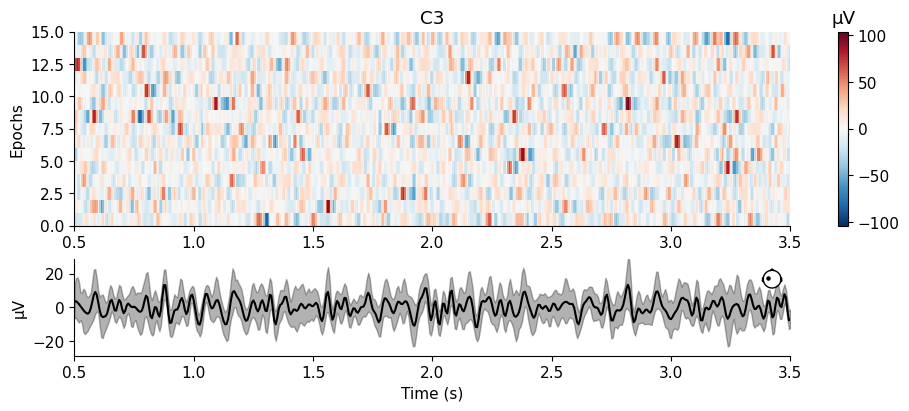

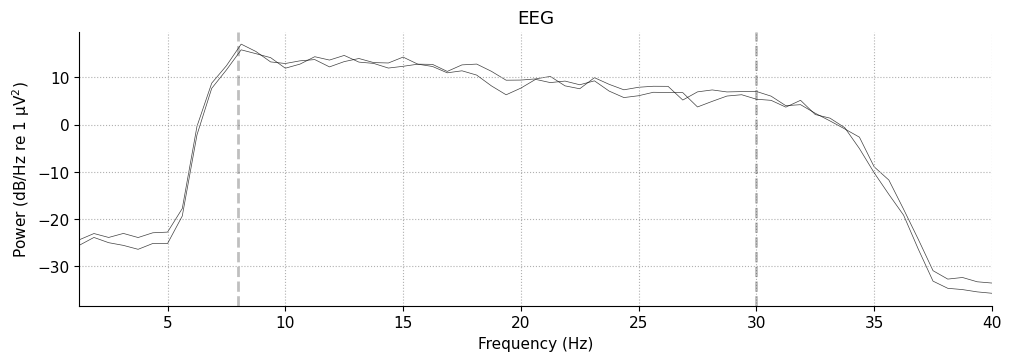

In [11]:
epochs.plot_image(picks=['C3'], sigma=0, show=False)
plt.show()
spectrum = epochs.compute_psd(method='welch', fmin=1, fmax=40, n_fft=256, verbose=False)
spectrum.plot(picks=['C3', 'C4'], average=False, spatial_colors=False, show=False)
plt.show()

## Interoperability and reproducible derivatives

`get_data(copy=True)` returns a NumPy array independent of subsequent array edits. The array has no intrinsic channel names, units or trial identifiers. Preserve `ch_names`, `times`, event labels and group metadata alongside exported arrays. Machine-learning estimators may require flattened features $(N,d)$ or accept epoch tensors $(N,C,T)$; inspect the estimator contract.

Filtering a complete recording and fitting a supervised transform are different operations. In a predictive evaluation, scalers, CSP, feature selection and parameter tuning must be fitted using training observations only. Using MNE objects does not prevent statistical leakage automatically.

MNE's native FIF serialization retains substantially more measurement context than an unlabeled CSV. Save processing parameters, software versions and dataset identifiers as a separate provenance record. A saved epoch file is a derivative, not a replacement for the original acquisition files. A seed improves reproducibility but does not guarantee identical results across all software and hardware configurations.

### Exercise 4: reproducibility audit

Specify the information needed to reproduce the epoch construction independently. Include at least one item from each category: data, timing, processing, environment and observation identity.

### Reference answer

Record the dataset/subject/run; event-code mapping and epoch limits; reference, filter and baseline settings; package versions; and trial events or metadata. For machine learning, additionally record group partitions, estimator parameters and random states. A final accuracy value alone is insufficient.

In [12]:
import json
output_dir = Path('mne_foundations_results')
output_dir.mkdir(exist_ok=True)
epoch_file = output_dir / 'subject01_run04-epo.fif'
epochs.save(epoch_file, overwrite=True, verbose=False)
provenance = {'dataset': 'PhysioNet EEGBCI', 'subject': 1, 'runs': [4],
              'mne_version': mne.__version__, 'event_id': epochs.event_id,
              'tmin': epochs.tmin, 'tmax': epochs.tmax, 'baseline': None,
              'filter_hz': [8, 30], 'channel_names': epochs.ch_names,
              'reference': 'as acquired; no additional rereferencing in this example'}
(output_dir / 'provenance.json').write_text(json.dumps(provenance, indent=2))
reloaded = mne.read_epochs(epoch_file, preload=True, verbose=False)
assert reloaded.ch_names == epochs.ch_names
assert np.array_equal(reloaded.events, epochs.events)
assert np.allclose(reloaded.get_data(), epochs.get_data(), rtol=1e-5, atol=1e-12)
print('Derivative and provenance saved; reload checks passed.')

Derivative and provenance saved; reload checks passed.


## Synthesis exercise

Design a sensor-level analysis for a P300 experiment using the object model introduced here. State what belongs in `Raw`, what defines an epoch, what an `Evoked` object represents, and what additional information is required for character selection. Explain why a motor-imagery spectrum and a P300 average address different physiological questions.

### Worked interpretation

`Raw` holds continuous EEG and acquisition metadata; flash onsets define epochs; target and non-target averages summarize their event-related responses. Character selection additionally needs flash identities, intended symbols and repetition/selection identifiers. Motor-imagery analysis often concerns induced power changes, while P300 analysis emphasizes stimulus-aligned waveform differences. Both require externally defined labels and an evaluation design appropriate to the intended application.

## Troubleshooting and completion criteria

- A montage mismatch requires checking channel names and types before changing positions.
- An empty epoch selection requires checking annotation descriptions, mapping, timing and rejection logs.
- Implausible amplitudes require checking units and reference before changing thresholds.
- Missing GUI support can be addressed with static Matplotlib-based displays.
- A large memory allocation requires reviewing preload, channel selection, epoch count and unnecessary copies.

Completion requires interpreting all saved figures, solving the dimension and unit exercises, distinguishing the synthetic construction from the recorded experiment, and explaining why metadata and validation design remain necessary after conversion to arrays.

## References

1. [Gramfort et al. (2013). MEG and EEG data analysis with MNE-Python. Frontiers in Neuroscience, 7, 267](https://doi.org/10.3389/fnins.2013.00267).
2. [MNE-Python: overview of MEG/EEG analysis](https://mne.tools/stable/auto_tutorials/intro/10_overview.html).
3. [MNE-Python: most-used classes](https://mne.tools/stable/api/most_used_classes.html).
4. [MNE-Python: modifying data in place](https://mne.tools/stable/auto_tutorials/intro/15_inplace.html).
5. [PhysioNet EEG Motor Movement/Imagery Dataset, version 1.0.0](https://physionet.org/content/eegmmidb/1.0.0/).
6. [MNE-Python `Epochs` API](https://mne.tools/stable/generated/mne.Epochs.html).
7. [MOABB API: datasets, paradigms and evaluations](https://moabb.neurotechx.com/docs/api.html).

Consult acquisition references for experimental facts and versioned software documentation for implementation behaviour. This tutorial describes public sensor-level workflows and contains no anatomical source-reconstruction exercises.